In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data import load_trades
from src.baselines import tick_rule
from src.classify_side import classify_side
from src.evaluate import compare_classifiers

trades = load_trades("WIFUSDT", "2026-04-14")

y_true = trades["side"].astype(bool)

tick_pred = tick_rule(trades)
xgb_pred = classify_side(trades)

comparison = compare_classifiers(
    trades,
    y_true,
    {
        "Tick Rule": tick_pred,
        "XGBoost": xgb_pred,
    },
)

comparison

,n,accuracy,macro_f1,buy_f1,sell_f1,balanced_accuracy
classifier,,,,,,
Tick Rule,29934,0.723525,0.722212,0.741310,0.703114,0.721895
XGBoost,29934,0.713236,0.701678,0.760397,0.642958,0.705067


In [2]:
xgb_pred_flipped = ~xgb_pred

comparison2 = compare_classifiers(
    trades,
    y_true,
    {
        "Tick Rule": tick_pred,
        "XGBoost": xgb_pred,
        "XGBoost Flipped": xgb_pred_flipped,
    },
)

comparison2

,n,accuracy,macro_f1,buy_f1,sell_f1,balanced_accuracy
classifier,,,,,,
Tick Rule,29934,0.723525,0.722212,0.741310,0.703114,0.721895
XGBoost,29934,0.713236,0.701678,0.760397,0.642958,0.705067
XGBoost Flipped,29934,0.286764,0.271203,0.164710,0.377696,0.294933


In [3]:
trades_val = load_trades("WIFUSDT", "2026-04-13")

y_val = trades_val["side"].astype(bool)

tick_val = tick_rule(trades_val)
xgb_val = classify_side(trades_val)

compare_classifiers(
    trades_val,
    y_val,
    {
        "Tick Rule": tick_val,
        "XGBoost": xgb_val,
    },
)

,n,accuracy,macro_f1,buy_f1,sell_f1,balanced_accuracy
classifier,,,,,,
Tick Rule,14868,0.708232,0.708153,0.712981,0.703324,0.708145
XGBoost,14868,0.700027,0.699456,0.712555,0.686357,0.699526


In [4]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from src.models.gbm import MODEL_PATH

bundle = joblib.load(MODEL_PATH)

model = bundle["model"]
feature_names = bundle["feature_names"]

importance = pd.Series(
    model.feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

importance.head(15)

run_dir         0.442518
tick_ff         0.314895
pct_range_20    0.032301
log_dt_s        0.019324
log_price       0.017251
dt_s            0.016816
pct_range_50    0.013640
frac_price      0.013421
log_amount      0.012898
tick_4          0.012810
tick_5          0.012241
ret_3           0.011088
run_length      0.010892
tick_3          0.010343
tick_2          0.009693
dtype: float32

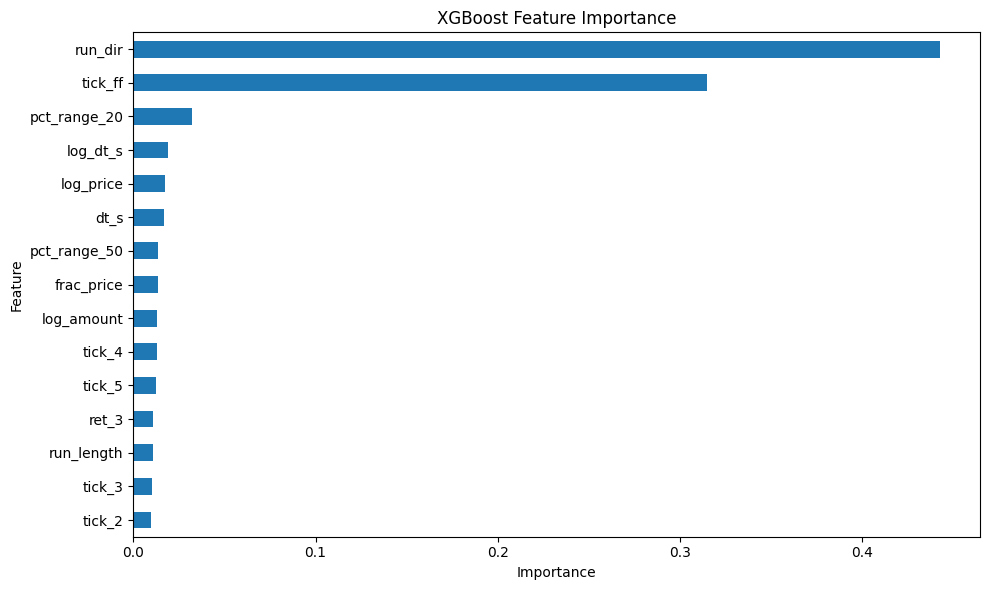

In [5]:
plt.figure(figsize=(10, 6))

importance.head(15).sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()